# Fine-Tuned SLM (DistilBERT + LoRA) — 30-Day Readmission from Notes

Thin runner/display layer only — all preprocessing, fine-tuning, and CV logic lives in `src/nlp/preprocess.py` and `src/models/train_slm.py`. This notebook does not reimplement any of it.

**This notebook trains and evaluates on SYNTHETIC note text (`data/mock/NOTEEVENTS.csv`), not real clinical data.** The real MIMIC-III demo's `NOTEEVENTS` table is empty (see `notebooks/01_eda.ipynb`); these synthetic notes have a deliberate, artificial correlation with the readmission label baked in by construction (see `data/generate_mock_noteevents.py`). Everything below is a pipeline sanity check — proof the fine-tuning pipeline runs end-to-end — **not a real finding about text-based readmission prediction.**

In [1]:
import os
import sys
from pathlib import Path

# xgboost (Homebrew libomp) and torch (bundled OpenMP) both load an OpenMP
# runtime; importing both in one process segfaults inside __kmp_fork_barrier
# without this. Must be set before either library is imported.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.nlp.preprocess import clean_text, load_notes_with_labels
from src.models.train_slm import run_cv

## Load notes + labels

In [2]:
df = load_notes_with_labels(
    data_dir=Path("..") / "data" / "raw",
    notes_path=Path("..") / "data" / "mock" / "NOTEEVENTS.csv",
)

n_pos = df["readmit_30d"].sum()
print(f"cohort: {len(df)} admissions with notes")
print(f"positives: {n_pos} ({100 * df['readmit_30d'].mean():.1f}%)")

cohort: 129 admissions with notes
positives: 11 (8.5%)


## Class balance

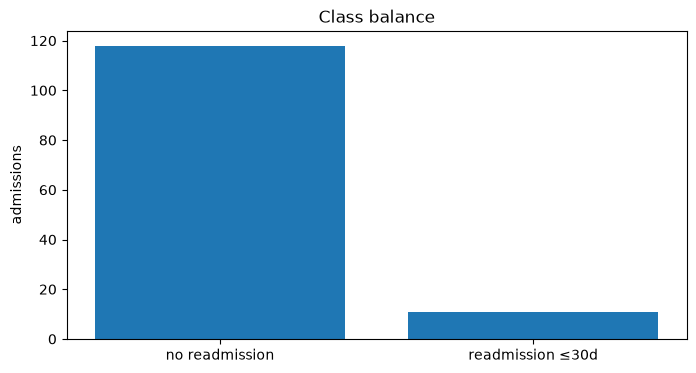

In [3]:
plt.figure(figsize=(8, 4))
plt.bar(["no readmission", "readmission \u226430d"], [len(df) - n_pos, n_pos])
plt.ylabel("admissions")
plt.title("Class balance")
plt.show()

## Example note (raw vs. cleaned)

Sanity check that `clean_text()` strips the synthetic-data marker before tokenization.

In [4]:
raw_notes = pd.read_csv(Path("..") / "data" / "mock" / "NOTEEVENTS.csv")
example = raw_notes.iloc[0]["text"]
print("RAW:\n", example)
print("\nCLEANED:\n", clean_text(example))

RAW:
 [SYNTHETIC NOTE -- generated for pipeline development, NOT real clinical text] Patient is a 70-year-old female admitted with Sepsis. Additional diagnoses noted during this admission: React-oth vasc dev/graft, Hyp kid NOS w cr kid V, Atrial fibrillation. Length of stay was approximately 9 day(s). Course included an ICU stay. Patient tolerated the hospital course well and was discharged in stable condition. Follow-up care was arranged as clinically indicated.

CLEANED:
 Patient is a 70-year-old female admitted with Sepsis. Additional diagnoses noted during this admission: React-oth vasc dev/graft, Hyp kid NOS w cr kid V, Atrial fibrillation. Length of stay was approximately 9 day(s). Course included an ICU stay. Patient tolerated the hospital course well and was discharged in stable condition. Follow-up care was arranged as clinically indicated.


## Cross-validated LoRA fine-tuning

In [5]:
report, models = run_cv(df)
report

HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"


HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"


HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


/Users/tjscanlan/Personal-Projects/mimic3-db-demo/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


fold 5: roc_auc=0.587 pr_auc=0.300


,fold,n_test,n_pos_test,roc_auc,pr_auc
0,1,26,2,0.916667,0.450000
1,2,26,2,0.791667,0.226190
2,3,26,2,0.812500,0.250000
3,4,26,3,0.782609,0.451389
4,5,25,2,0.586957,0.300000


In [6]:
print(f"roc_auc  mean={report['roc_auc'].mean():.3f}  std={report['roc_auc'].std():.3f}")
print(f"pr_auc   mean={report['pr_auc'].mean():.3f}  std={report['pr_auc'].std():.3f}")

roc_auc  mean=0.778  std=0.120
pr_auc   mean=0.336  std=0.108


## Comparison to structured baseline (step 2)

Re-running the step-2 baseline live (not hardcoding its old numbers) so this comparison can't go stale. Run as a **subprocess**, not imported in-process: `xgboost` (Homebrew `libomp`) and `torch` (bundled OpenMP) both loading in the same interpreter segfaults (`SIGSEGV` in `__kmp_fork_barrier` — confirmed via macOS crash report; `KMP_DUPLICATE_LIB_OK=TRUE` does not fix it, since this is a genuine thread-pool incompatibility, not just a spurious duplicate-load warning).

In [7]:
import json
import subprocess
import sys
import tempfile

with tempfile.TemporaryDirectory() as tmp_dir:
    baseline_json = Path(tmp_dir) / "baseline_report.json"
    subprocess.run(
        [
            sys.executable, "-m", "src.models.train_baseline",
            "--json-out", str(baseline_json),
        ],
        cwd=Path("..").resolve(),
        check=True,
        capture_output=True,
    )
    baseline_report = pd.DataFrame(json.loads(baseline_json.read_text()))

comparison = pd.DataFrame(
    {
        "model": ["structured (XGBoost)", "text (DistilBERT+LoRA)"],
        "roc_auc_mean": [baseline_report["roc_auc"].mean(), report["roc_auc"].mean()],
        "roc_auc_std": [baseline_report["roc_auc"].std(), report["roc_auc"].std()],
        "pr_auc_mean": [baseline_report["pr_auc"].mean(), report["pr_auc"].mean()],
        "pr_auc_std": [baseline_report["pr_auc"].std(), report["pr_auc"].std()],
    }
)
comparison

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,structured (XGBoost),0.561413,0.174735,0.174924,0.116282
1,text (DistilBERT+LoRA),0.778080,0.119503,0.335516,0.108466


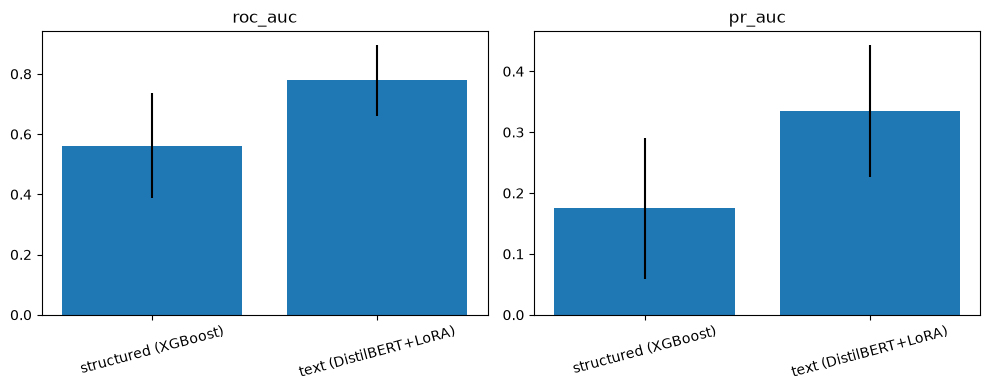

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["roc_auc", "pr_auc"]):
    ax.bar(
        comparison["model"],
        comparison[f"{metric}_mean"],
        yerr=comparison[f"{metric}_std"],
    )
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### Caveat: this comparison is not apples-to-apples

The structured model is evaluated on **real** MIMIC-III demo data. The text model is evaluated on **synthetic** notes with an artificially injected correlation to the label — by construction, not a discovery. A fair text-vs-structured comparison requires real discharge-summary text, which the demo dataset doesn't provide (blocked on full credentialed MIMIC-III access). The purpose of this notebook is solely to demonstrate that the LoRA fine-tuning + per-fold weighted-loss + cross-validation pipeline runs correctly end-to-end, ready to point at real note text once it's available.